In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

In [3]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

In [15]:
# when we don't declare an observation in the model, the samplers smaple from the prior dists
# these can then be plotted (see further below)
with pm.Model() as model:
    mu1 = pm.Normal("mu1", mu=0, sigma=0.2)
    mu2 = pm.Normal("mu2", mu=1.0, sigma=1)
    # obs = pm.Normal("obs", mu=1, sigma=1, observed=rng.standard_normal(100))
    # Sample from the posterior
    trace = pm.sample(5000, tune=1000, chains=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu1, mu2]


Output()

Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 6 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [16]:
model.basic_RVs

[mu1 ~ Normal(0, 0.2), mu2 ~ Normal(1, 1)]

In [17]:
model.free_RVs

[mu1 ~ Normal(0, 0.2), mu2 ~ Normal(1, 1)]

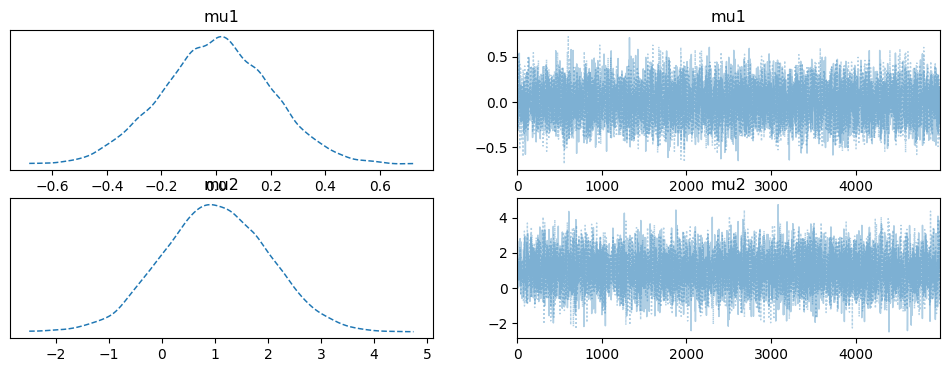

In [18]:
az.plot_trace(trace, combined=True);

In [19]:
az.summary(trace, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu1,0.00,0.2,-0.38,0.38,0.00,0.00,10129.00,7959.37,1.0
mu2,1.01,1.0,-0.81,2.90,0.01,0.01,9555.41,7976.65,1.0


In [20]:
# this requires python-graphviz, but for some reason i cannot install this using uv add python-graphviz
pm.model_to_graphviz(model)

ImportError: This function requires the python library graphviz, along with binaries. The easiest way to install all of this is by running

	conda install -c conda-forge python-graphviz

In [40]:
# if we dont provide an observation, we seem to get samples for the priors and the posterior
with pm.Model() as model:
    beta = pm.Beta("beta", alpha = 0.5, beta = 1)
    obs = pm.Binomial("obs", n = 100, p = beta)
    # Sample from the posterior
    trace = pm.sample(5000, tune=1000, chains=2)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>NUTS: [beta]
>Metropolis: [obs]


Output()

Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


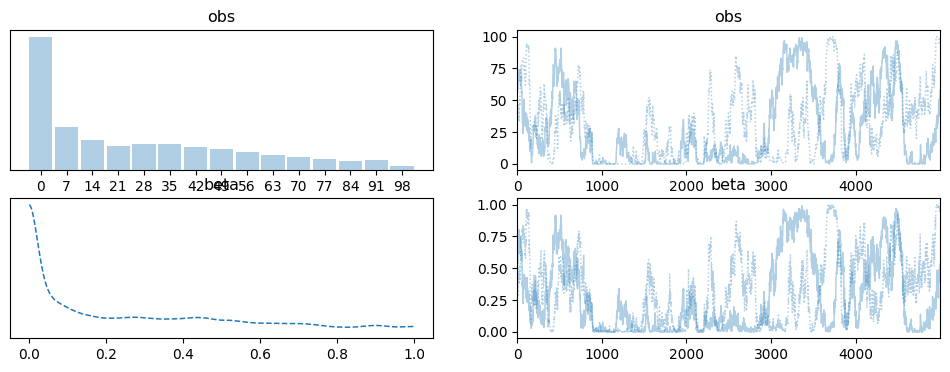

In [44]:
az.plot_trace(trace, combined=True);

In [45]:
az.summary(trace, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
obs,28.90,28.30,0.0,83.00,5.07,2.02,21.73,45.03,1.11
beta,0.29,0.28,0.0,0.83,0.05,0.02,21.28,87.00,1.10
